# OCR Lens

The OCR lens reads words off the scene without a text query. The scene's keyframes go in, and
out comes, for every mesh vertex, the words its surface most likely shows, each with a
probability.

The lens runs a vision-language model (LLaVA-1.6) over each keyframe and reads its hidden
states through the attention heads that do OCR. The model's language head then turns each image
patch into a probability distribution over a word vocabulary. The weights must already be in
the local Hugging Face cache; the page sets `HF_HUB_OFFLINE=1` so nothing is downloaded.

In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import torch
import transformers
import zarr
from matplotlib.colors import ListedColormap

from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc.frames import frame_paths
from collab_splats.reconstructor import store_rows
from collab_splats.semantics import FeatureAutoencoder
from collab_splats.semantics.features.ocr_lens import (
    load_decoder,
    load_processor,
    word_probabilities,
    word_vocabulary,
)
from collab_splats.utils.io import read_image

# Use the cached LLaVA weights only; set before the model libraries load
os.environ["HF_HUB_OFFLINE"] = "1"
transformers.logging.set_verbosity_error()

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "mesh", "semantics", extractor="ocr_lens")

# Image panels without pixel axes
BARE = {"frame_on": False, "xticks": [], "yticks": []}

## 1. What the lens stores

The semantics stage writes `semantics/ocr_lens_lifted.zarr` next to `mesh.ply`. Next to the
per-point codes it holds two arrays indexed by mesh vertex: the ids of each vertex's 64 most
likely words, best first, and their probabilities. The `words` attribute is the vocabulary
those ids index into, and `mesh_sha256` records which `mesh.ply` the rows belong to.

The stage decodes each frame's patches to word probabilities before lifting them onto the
vertices. The decoder ends in an RMSNorm, which is not linear, so decoding a vertex's averaged
features would not give the average of its per-view words.

In [2]:
store = zarr.open(str(scene.outputs["semantics"]), mode="r")
word_ids = np.asarray(store["vertex_word_ids"])
word_probs = np.asarray(store["vertex_word_probs"], dtype=np.float32)
words = list(store.attrs["words"])

print(f"vertex_word_ids   {word_ids.shape}")
print(f"vertex_word_probs {word_probs.shape}")
print(f"vocabulary        {len(words):,} words")

vertex_word_ids   (293962, 64)
vertex_word_probs (293962, 64)
vocabulary        3,512 words


## 2. Top words

A vertex no keyframe saw has all-zero probabilities, so the first column tells observed
vertices apart. Counting each observed vertex's top-1 word shows what the scene's surfaces
mostly read as.

In [3]:
observed = word_probs[:, 0] > 0
print(f"{observed.mean():.1%} of {len(observed):,} vertices observed")

# Count each observed vertex's best word, most common first
top1 = word_ids[observed, 0]
counts = np.bincount(top1, minlength=len(words))
ranked = np.argsort(counts)[::-1]

for row in ranked[:10]:
    print(f"{words[row]:15s} {counts[row]:>8,} vertices")

98.3% of 293,962 vertices observed
forest            66,765 vertices
tree              64,081 vertices
log               28,107 vertices
leave             22,640 vertices
grass             16,148 vertices
branch            12,846 vertices
ground             8,697 vertices
road               7,911 vertices
leaf               6,809 vertices
rock               4,991 vertices


## 3. One keyframe

The stage keeps every keyframe's lens states as 64-D autoencoder codes in
`semantics/ocr_lens_codes.zarr`, at the scene level. Decoding a frame needs only the autoencoder
and the model's final norm and language head (`load_decoder`, about 260 MB), not the 7B model.
This is the same decode the stage runs before lifting.

In [4]:
# Keyframe 0's row in the scene-level codes store
codes_path = scene.semantics_cache_dir / "ocr_lens_codes.zarr"
codes = zarr.open(str(codes_path), mode="r")["features"]
cloud = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_world_points=False)
row = store_rows(scene.images_dir, cloud.image_paths)[0]

# Autoencoder, final norm + language head, and the stage's word vocabulary
model_id = "llava-hf/llava-v1.6-vicuna-7b-hf"
ae = FeatureAutoencoder.load(codes_path / "autoencoder.pt").to("cuda")
decoder = load_decoder(model_id)
vocab = word_vocabulary(load_processor(model_id).tokenizer)

# Patch codes as rows, decoded to word probabilities; ids index the same `words` as the store
fmap = torch.from_numpy(codes[row]).float()
channels, height, width = fmap.shape
states = fmap.reshape(channels, -1).T
patch_probs = torch.cat([p for p, _ in word_probabilities(states, decoder, vocab, ae=ae)])
patch_probs = patch_probs.cpu().numpy()
print(f"patch grid {height} x {width}, {patch_probs.shape[1]:,} words")

patch grid 48 x 28, 3,512 words


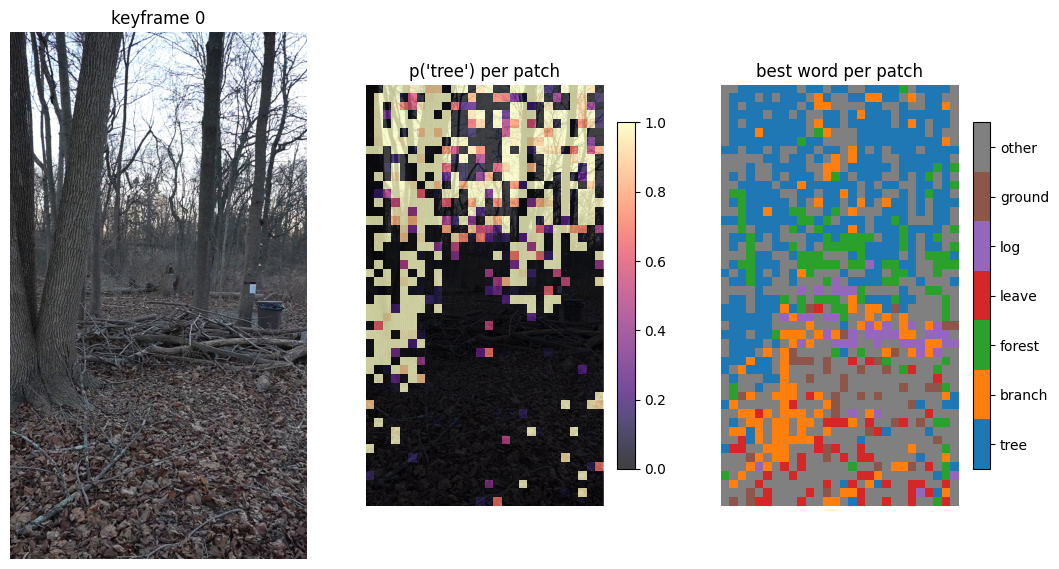

In [5]:
# Probe one word; its id indexes the same vocabulary as the store
probe = "tree"
probe_id = words.index(probe)
probe_map = patch_probs[:, probe_id].reshape(height, width)

# Each patch's best word; the frame's six most common keep a color, the rest are "other"
best = patch_probs.argmax(axis=1)
ids, counts = np.unique(best, return_counts=True)
common = ids[np.argsort(counts)[::-1][:6]]
labels = np.full(len(best), len(common))

for k, word_id in enumerate(common):
    labels[best == word_id] = k

# Frame, probe heat over it, and the best-word map, on the frame's pixel extent
image = np.asarray(read_image(frame_paths(scene.images_dir)[row]))
extent = (0, image.shape[1], image.shape[0], 0)
colors = [*matplotlib.colormaps["tab10"].colors[: len(common)], "grey"]
fig, axes = plt.subplots(1, 3, figsize=(13, 7.5), subplot_kw=BARE)
axes[0].imshow(image)
axes[1].imshow(image)
heat = axes[1].imshow(probe_map, cmap="magma", alpha=0.75, vmin=0, vmax=1, extent=extent)
best_map = labels.reshape(height, width)
best_cmap = ListedColormap(colors)
cats = axes[2].imshow(best_map, cmap=best_cmap, vmin=-0.5, vmax=len(common) + 0.5, extent=extent)

for ax, title in zip(axes, ["keyframe 0", f"p({probe!r}) per patch", "best word per patch"]):
    ax.set_title(title)

fig.colorbar(heat, ax=axes[1], shrink=0.6)
legend = fig.colorbar(cats, ax=axes[2], shrink=0.6, ticks=range(len(common) + 1))
legend.set_ticklabels([words[i] for i in common] + ["other"])
plt.show()

Patches read word by word: the canopy as "tree", the brush pile as "log", the sticks in the
foreground as "branch". A single patch's best word is noisy; lifting averages each vertex's
probabilities over every keyframe that saw it.

## 4. Probing a word

A word's probability at a vertex is its stored probability when it is among that vertex's top
64, and zero otherwise. Here the probe from the keyframe above is drawn as heat on the mesh, from
the same camera; unobserved vertices are grey.

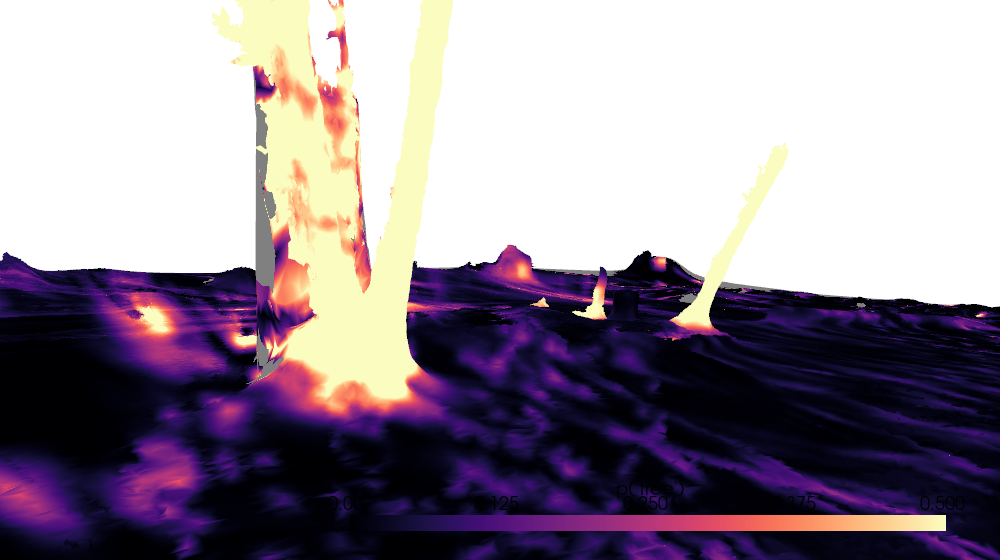

In [6]:
hit = word_ids == probe_id
scores = (word_probs * hit).sum(axis=1)
scores[~observed] = np.nan

# Look out of keyframe 0's camera: w2c to c2w, OpenCV axes (y down, z forward)
c2w = np.linalg.inv(cloud.extrinsics[0])
eye = c2w[:3, 3]
plotter = pv.Plotter(window_size=(1000, 560))
plotter.add_mesh(
    pv.read(scene.outputs["mesh"]),
    scalars=scores,
    cmap="magma",
    clim=(0, 0.5),
    nan_color="grey",
    lighting=False,
    scalar_bar_args={"title": f"p({probe!r})"},
)
plotter.camera_position = [eye, eye + c2w[:3, 2], -c2w[:3, 1]]
plotter.camera.view_angle = 60
plotter.show()

The trunks read as "tree" across the whole surface, where a single keyframe's patches were
patchy; the ground stays dark. The color range stops at 0.5 so surfaces where "tree" is one of
several likely words still show.

## In a pipeline run

The semantics stage does all of the above when the extractor is `ocr_lens` and `mesh.ply`
exists:

```yaml
semantics:
  extractor: ocr_lens
```

The scene viewer serves the mesh in a browser with a word query, a ranked label list and a click
probe over the same store:

```bash
python -m collab_splats.viewer data/tutorial_scene/vggt_omega --port 8080
```